In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv("intern_performance.csv")
data.head()

,Attendance,Feedback_Rating,Task_Completion_Time,Performance_Score
0,95,4.8,3,94
1,90,4.5,4,90
2,85,4.2,5,85
3,80,4.0,6,80
4,75,3.8,7,75


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Attendance            20 non-null     int64  
 1   Feedback_Rating       20 non-null     float64
 2   Task_Completion_Time  20 non-null     int64  
 3   Performance_Score     20 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 772.0 bytes


In [4]:
data.describe()

,Attendance,Feedback_Rating,Task_Completion_Time,Performance_Score
count,20.000000,20.000000,20.000000,20.000000
mean,84.450000,4.180000,5.200000,84.150000
std,9.472814,0.534691,2.067289,9.466145
min,65.000000,3.200000,2.000000,65.000000
25%,77.500000,3.775000,3.750000,76.750000
50%,85.500000,4.200000,5.000000,85.500000
75%,91.250000,4.625000,7.000000,91.500000
max,98.000000,5.000000,9.000000,98.000000


In [5]:
# Features (Input)
X = data[["Attendance", "Feedback_Rating", "Task_Completion_Time"]]

# Target (Output)
y = data["Performance_Score"]

print(X.head())
print(y.head())

   Attendance  Feedback_Rating  Task_Completion_Time
0          95              4.8                     3
1          90              4.5                     4
2          85              4.2                     5
3          80              4.0                     6
4          75              3.8                     7
0    94
1    90
2    85
3    80
4    75
Name: Performance_Score, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 16
Testing Data: 4


In [7]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [8]:
predictions = model.predict(X_test)

print("Predicted Values:")
print(predictions)

Predicted Values:
[95.51 84.77 95.71 88.91]


In [9]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.1350000000000016
Mean Squared Error (MSE): 1.371300000000006
R² Score: 0.8919172413793098


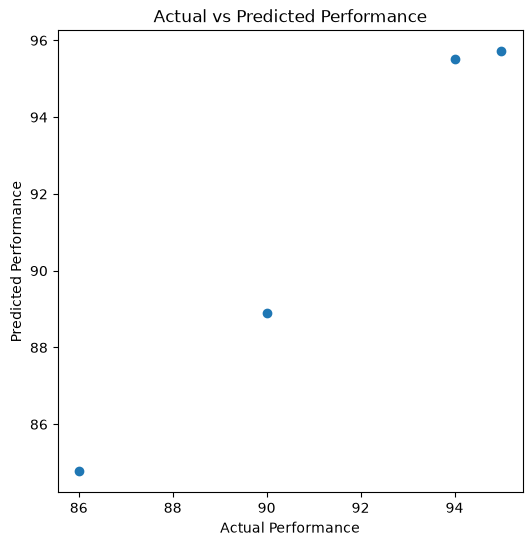

In [10]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("Actual vs Predicted Performance")

plt.show()

In [11]:
joblib.dump(model, "intern_performance_model.pkl")

print("Model saved successfully!")

Model saved successfully!
